In [4]:
import yfinance as yf
import pandas as pd

ticker = "RELIANCE.NS"
df = yf.download(ticker, period="24mo", interval="1d", auto_adjust=True)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df[['Close']].dropna()

[*********************100%***********************]  1 of 1 completed


In [5]:
df['EMA20'] = df['Close'].ewm(span=20, adjust=False).mean()
df['EMA50'] = df['Close'].ewm(span=50, adjust=False).mean()

In [6]:
cutoff = df.index.max() - pd.DateOffset(months=12)
df = df[df.index >= cutoff].copy()

In [7]:
df['signal'] = (df['EMA20'] > df['EMA50']).astype(int)
df['change'] = df['signal'].diff()

entries = df.index[df['change'] == 1]
exits = df.index[df['change'] == -1]

In [9]:
trades = []
exit_list = list(exits)
for i, entry_date in enumerate(entries):
    matching_exits = [e for e in exit_list if e > entry_date]
    if matching_exits:
        exit_date = matching_exits[0]
        entry_price = df.loc[entry_date, 'Close']
        exit_price = df.loc[exit_date, 'Close']
        pnl_pct = (exit_price - entry_price) / entry_price * 100
        trades.append({
            "Trade #": i + 1,
            "Entry Date": entry_date.date(),
            "Entry Price": round(float(entry_price), 2),
            "Exit Date": exit_date.date(),
            "Exit Price": round(float(exit_price), 2),
            "P&L %": round(float(pnl_pct), 2),
        })
    else:
        entry_price = df.loc[entry_date, 'Close']
        print(f"NOTE: trade entered {entry_date.date()} at {entry_price:.2f} is still OPEN (no exit yet)")

trade_log = pd.DataFrame(trades)
print(trade_log)

   Trade #  Entry Date  Entry Price   Exit Date  Exit Price  P&L %
0        1  2025-10-21      1458.46  2026-01-15     1452.09  -0.44
1        2  2026-05-06      1431.28  2026-05-13     1352.55  -5.50


In [13]:
total_trades = len(trade_log)
winners = trade_log[trade_log['P&L %'] > 0]
win_rate = len(winners) / total_trades * 100 if total_trades else 0
largest_winner = trade_log['P&L %'].max() if total_trades else None
largest_loser = trade_log['P&L %'].min() if total_trades else None

summary = {
    "Total Trades": total_trades,
    "Number of Winners": len(winners),
    "Win Rate (%)": round(win_rate, 2),
    "Largest Winner (%)": largest_winner,
    "Largest Loser (%)": largest_loser,
}
print(summary)

{'Total Trades': 2, 'Number of Winners': 0, 'Win Rate (%)': 0.0, 'Largest Winner (%)': np.float64(-0.44), 'Largest Loser (%)': np.float64(-5.5)}


In [14]:
trade_log.to_csv("reliance_trade_log.csv", index=False)
with open("reliance_trade_log.csv", "a") as f:
    f.write("\n")
    pd.DataFrame([summary]).to_csv(f, index=False)

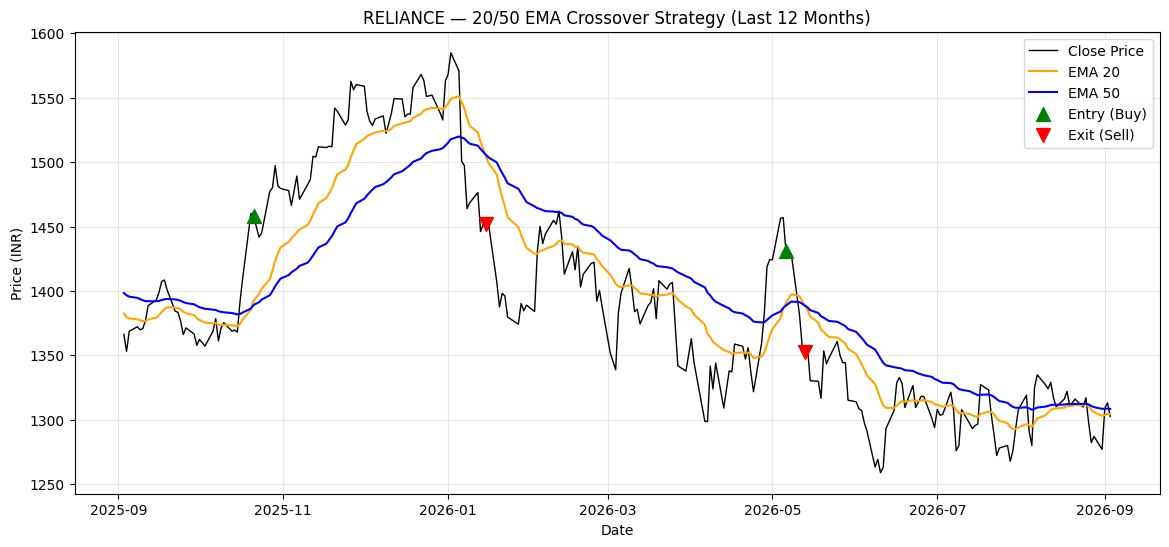

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], label='Close Price', color='black', linewidth=1)
plt.plot(df.index, df['EMA20'], label='EMA 20', color='orange', linewidth=1.5)
plt.plot(df.index, df['EMA50'], label='EMA 50', color='blue', linewidth=1.5)
plt.scatter(trade_log['Entry Date'], trade_log['Entry Price'], color='green', marker='^', s=100, zorder=5, label='Entry (Buy)')
plt.scatter(trade_log['Exit Date'], trade_log['Exit Price'], color='red', marker='v', s=100, zorder=5, label='Exit (Sell)')
plt.title('RELIANCE — 20/50 EMA Crossover Strategy (Last 12 Months)')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()